In [1]:
import os, sys, math, time, random
from pathlib import Path

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved to:", OUT_DIR.resolve())

Outputs will be saved to: C:\Users\nizar\Desktop\variant C\outputs


In [2]:
import sys, subprocess, textwrap

pkgs = [
    "datasets>=2.18.0",
    "torchmetrics>=1.3.0",
    "scikit-learn>=1.3.0",
    "matplotlib>=3.8.0",
    "reportlab>=4.0.0",
    "tqdm>=4.66.0",
    "torchvision>=0.17.0",
]
cmd = [sys.executable, "-m", "pip", "install", "-q"] + pkgs
print("Running:", " ".join(cmd))
subprocess.check_call(cmd)
print("Done.")

Running: c:\Users\nizar\Desktop\variant C\.venv\Scripts\python.exe -m pip install -q datasets>=2.18.0 torchmetrics>=1.3.0 scikit-learn>=1.3.0 matplotlib>=3.8.0 reportlab>=4.0.0 tqdm>=4.66.0 torchvision>=0.17.0
Done.


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

c:\Users\nizar\Desktop\variant C\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [4]:
ds = load_dataset("AI-Lab-Makerere/beans")
print(ds)

label_names = ds["train"].features["labels"].names
num_classes = len(label_names)
print("Classes:", label_names)

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']


In [5]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

viz_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [6]:
def transform_batch(batch):
    images = batch["image"]
    batch["pixel_values"] = [train_tfms(img) for img in images]
    return batch

def transform_batch_eval(batch):
    images = batch["image"]
    batch["pixel_values"] = [eval_tfms(img) for img in images]
    return batch

train_ds = ds["train"].with_transform(transform_batch)
val_ds   = ds["validation"].with_transform(transform_batch_eval)
test_ds  = ds["test"].with_transform(transform_batch_eval)

def collate_fn(batch):
    x = torch.stack([b["pixel_values"] for b in batch])
    y = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
    return x, y

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

print(len(train_loader), len(val_loader), len(test_loader))

33 5 4


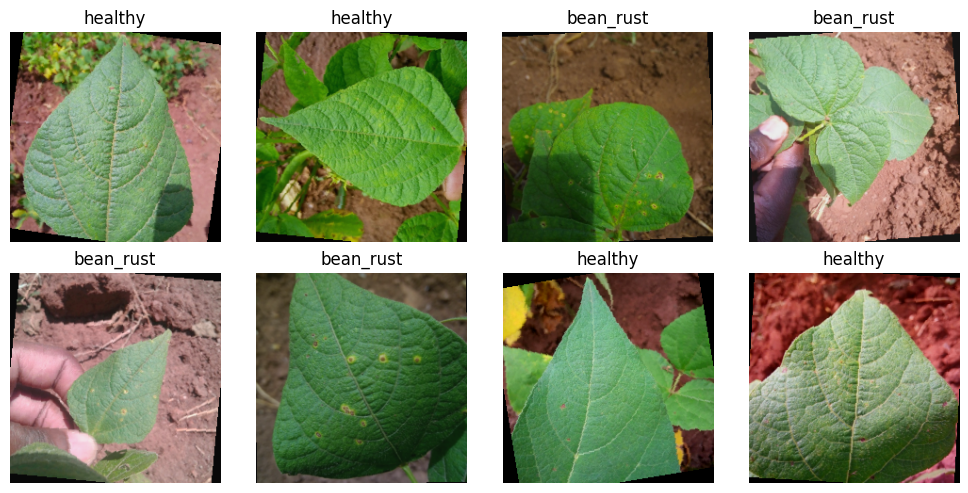

Saved: C:\Users\nizar\Desktop\variant C\outputs\sample_images.png


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def denormalize(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))

imgs = imgs[:8].cpu()
labels = labels[:8].cpu()

imgs_dn = denormalize(imgs)

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.transpose(imgs_dn[i].numpy(), (1, 2, 0)))
    plt.title(label_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()

out_path = OUT_DIR / "sample_images.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path.resolve())

In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses = []
    correct = 0
    total = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return float(np.mean(losses)), correct/total

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    losses = []
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return float(np.mean(losses)), correct/total

def fit(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=0.0, patience=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val = -1.0
    best_path = OUT_DIR / f"best_{model.__class__.__name__}.pt"
    wait = 0

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = eval_one_epoch(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

        if va_acc > best_val + 1e-4:
            best_val = va_acc
            wait = 0
            torch.save(model.state_dict(), best_path)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_val, best_path

In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = (IMG_SIZE // 4) * (IMG_SIZE // 4) * 32
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

baseline = BaselineCNN(num_classes)
baseline

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [10]:
baseline, hist_base, best_val_base, best_path_base = fit(
    baseline,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    weight_decay=0.0,
    patience=5
)

print("Best baseline val acc:", best_val_base)
print("Saved to:", best_path_base)

Epoch 01/15 | train loss 2.2995 acc 0.4662 | val loss 0.8212 acc 0.5113


Epoch 02/15 | train loss 0.8870 acc 0.5841 | val loss 0.7905 acc 0.6165


Epoch 03/15 | train loss 0.8262 acc 0.6344 | val loss 0.7688 acc 0.5639


Epoch 04/15 | train loss 0.7767 acc 0.6567 | val loss 0.6493 acc 0.6992


Epoch 05/15 | train loss 0.7155 acc 0.6905 | val loss 0.6175 acc 0.6992


...

Epoch 11/15 | train loss 0.5003 acc 0.7950 | val loss 0.5184 acc 0.7744


Epoch 12/15 | train loss 0.4741 acc 0.7940 | val loss 0.6202 acc 0.6992


Epoch 13/15 | train loss 0.4512 acc 0.8124 | val loss 0.5561 acc 0.7068


Epoch 14/15 | train loss 0.4618 acc 0.8095 | val loss 0.4763 acc 0.7820


Epoch 15/15 | train loss 0.4378 acc 0.8085 | val loss 0.4807 acc 0.7519
Best baseline val acc: 0.7819548872180451
Saved to: outputs\best_BaselineCNN.pt


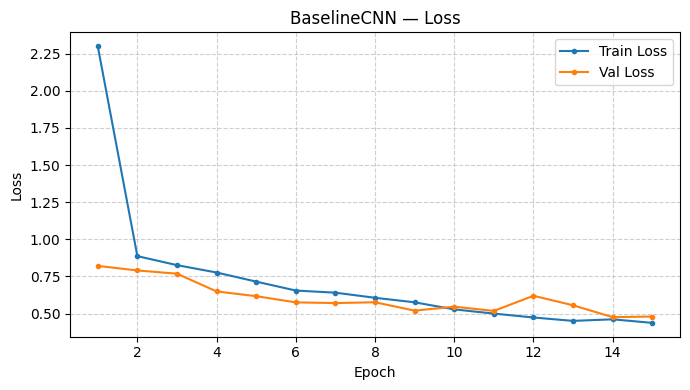

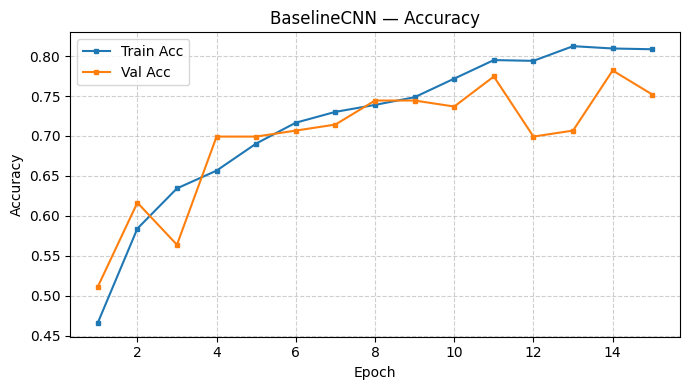

Learning curves saved to: outputs


In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title, out_path):
    """
    Plots training and validation curves for loss and accuracy.
    """
    if not history or "train_loss" not in history:
        print("Error: History object is empty or invalid.")
        return

    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker='o', markersize=3)
    plt.plot(epochs, history["val_loss"], label="Val Loss", marker='o', markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    loss_path = out_path.parent / f"{out_path.stem}_loss.png"
    plt.savefig(loss_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train Acc", marker='s', markersize=3)
    plt.plot(epochs, history["val_acc"], label="Val Acc", marker='s', markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    acc_path = out_path.parent / f"{out_path.stem}_acc.png"
    plt.savefig(acc_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Learning curves saved to: {out_path.parent}")

if __name__ == "__main__":
    try:
        plot_history(hist_base, "BaselineCNN", OUT_DIR / "learning_curves_baseline.png")
    except NameError:
        print("Error: 'hist_base' or 'OUT_DIR' not found. Make sure training finished successfully.")

In [12]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),   
            block(32, 64),  
            block(64, 128), 
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

improved = ImprovedCNN(num_classes)
improved

ImprovedCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(in

In [13]:
improved, hist_imp, best_val_imp, best_path_imp = fit(
    improved,
    train_loader,
    val_loader,
    epochs=20,
    lr=8e-4,
    weight_decay=1e-4,
    patience=7
)

print("Best improved val acc:", best_val_imp)
print("Saved to:", best_path_imp)

Epoch 01/20 | train loss 0.8609 acc 0.6044 | val loss 0.7144 acc 0.6165


Epoch 02/20 | train loss 0.7467 acc 0.6625 | val loss 0.6234 acc 0.6992


Epoch 03/20 | train loss 0.7272 acc 0.6789 | val loss 0.6115 acc 0.6541


Epoch 04/20 | train loss 0.6789 acc 0.7186 | val loss 0.5469 acc 0.6917


Epoch 05/20 | train loss 0.6758 acc 0.7224 | val loss 0.5542 acc 0.7143


...

Epoch 16/20 | train loss 0.4867 acc 0.8037 | val loss 0.3053 acc 0.9098


Epoch 17/20 | train loss 0.4511 acc 0.8288 | val loss 0.3446 acc 0.8647


Epoch 18/20 | train loss 0.4125 acc 0.8443 | val loss 0.3237 acc 0.8872


Epoch 19/20 | train loss 0.4448 acc 0.8279 | val loss 0.3379 acc 0.8872


Epoch 20/20 | train loss 0.4115 acc 0.8366 | val loss 0.3270 acc 0.8797
Best improved val acc: 0.9097744360902256
Saved to: outputs\best_ImprovedCNN.pt


In [14]:
import numpy as np
import torch

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_pred)

In [15]:
from sklearn.metrics import accuracy_score

y_true_base, y_pred_base = predict_all(baseline, test_loader)
test_acc_base = accuracy_score(y_true_base, y_pred_base)

y_true_imp, y_pred_imp = predict_all(improved, test_loader)
test_acc_imp = accuracy_score(y_true_imp, y_pred_imp)

print("Baseline test accuracy:", round(test_acc_base, 4))
print("Improved test accuracy:", round(test_acc_imp, 4))

Baseline test accuracy: 0.8203
Improved test accuracy: 0.8438


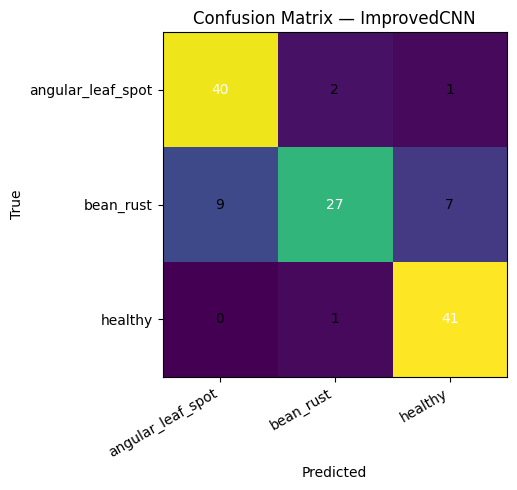

Saved: outputs\confusion_matrix_best.png


In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

best_model_name = "ImprovedCNN" if best_val_imp >= best_val_base else "BaselineCNN"
y_true_best, y_pred_best = (y_true_imp, y_pred_imp) if best_model_name == "ImprovedCNN" else (y_true_base, y_pred_base)

cm = confusion_matrix(y_true_best, y_pred_best, labels=list(range(num_classes)))

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), label_names, rotation=30, ha="right")
plt.yticks(range(num_classes), label_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
cm_path = OUT_DIR / "confusion_matrix_best.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

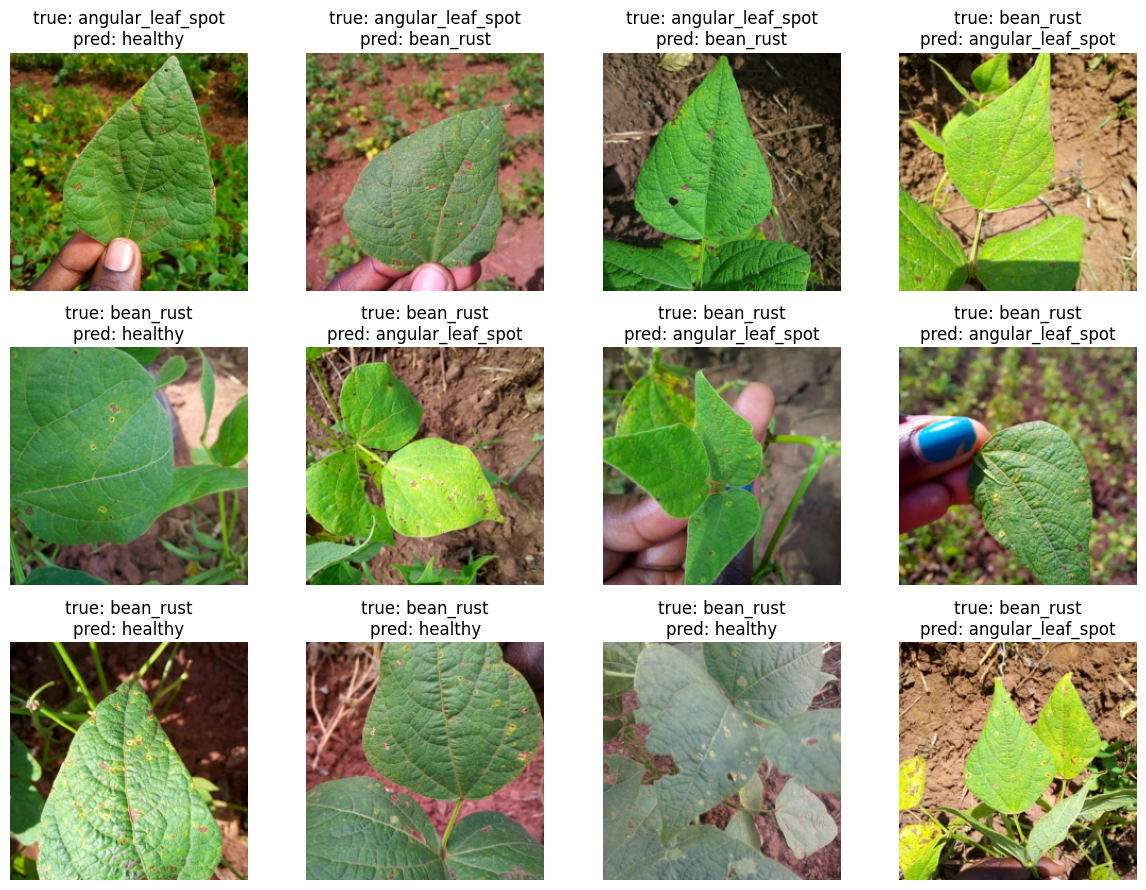

Saved: outputs\misclassified_examples.png


In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_misclassified(model, loader, max_items=12):
    model.eval()
    items = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        for i in range(x.size(0)):
            if preds[i].item() != y[i].item():
                items.append((x[i].cpu(), y[i].item(), preds[i].item()))
                if len(items) >= max_items:
                    return items
    return items

mis = collect_misclassified(improved if best_model_name=="ImprovedCNN" else baseline, test_loader, max_items=12)

def denormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (x*std + mean).clamp(0,1)

if len(mis) == 0:
    print("No misclassifications found.")
else:
    n = len(mis)
    cols = 4
    rows = math.ceil(n/cols)

    plt.figure(figsize=(12, 3*rows))
    for idx, (img_t, y_t, y_p) in enumerate(mis, start=1):
        img_dn = denormalize(img_t).numpy()
        plt.subplot(rows, cols, idx)
        plt.imshow(np.transpose(img_dn, (1,2,0)))
        plt.title(f"true: {label_names[y_t]}\npred: {label_names[y_p]}")
        plt.axis("off")
    plt.tight_layout()

    mis_path = OUT_DIR / "misclassified_examples.png"
    plt.savefig(mis_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", mis_path)

In [18]:
from pathlib import Path
import os

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors

OUT_DIR = globals().get("OUT_DIR", Path("outputs"))
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

def safe_float(name, default=0.0):
    v = globals().get(name, None)
    try:
        return float(v)
    except Exception:
        return float(default)

def pick_first_existing(names):
    for n in names:
        p = OUT_DIR / n
        if p.exists():
            return p
    return None

best_val_base = safe_float("best_val_base", 0.0)
test_acc_base = safe_float("test_acc_base", 0.0)

best_val_imp  = safe_float("best_val_imp", 0.0)
test_acc_imp  = safe_float("test_acc_imp", 0.0)

label_names = globals().get("label_names", ["class0", "class1", "class2"])
num_classes = len(label_names)

best_model_name = "ImprovedCNN" if best_val_imp >= best_val_base else "BaselineCNN"
best_test_acc = test_acc_imp if best_model_name == "ImprovedCNN" else test_acc_base


lc_base = pick_first_existing([
    "learning_curves_baseline.png",
    "learning_curves_baseline_loss.png",
    "learning_curves_baseline_acc.png",
])

lc_imp = pick_first_existing([
    "learning_curves_improved.png",
    "learning_curves_improved_loss.png",
    "learning_curves_improved_acc.png",
])

cm_path = pick_first_existing([
    "confusion_matrix_best.png",
    "confusion_matrix.png",
])

mis_path = pick_first_existing([
    "misclassified_examples.png",
    "failure_cases.png",
])


pdf_path = OUT_DIR / "Report_VariantC_Final.pdf"
styles = getSampleStyleSheet()
title = styles["Title"]
h2 = styles["Heading2"]
body = styles["BodyText"]

doc = SimpleDocTemplate(
    str(pdf_path),
    pagesize=A4,
    rightMargin=2.0*cm,
    leftMargin=2.0*cm,
    topMargin=1.5*cm,
    bottomMargin=1.5*cm
)

story = []


def add_fig(fig_path: Path, caption: str, max_w_cm=16.5, max_h_cm=10.5):
    if fig_path is None:
        story.append(Paragraph(f"{caption}: <i>(figure not found in outputs/)</i>", body))
        story.append(Spacer(1, 6))
        return

    story.append(Paragraph(caption, body))
    story.append(Spacer(1, 4))

    img = RLImage(str(fig_path))

    max_w = max_w_cm * cm
    max_h = max_h_cm * cm

    iw, ih = img.imageWidth, img.imageHeight
    scale = min(max_w / iw, max_h / ih)

    img.drawWidth  = iw * scale
    img.drawHeight = ih * scale

    story.append(img)
    story.append(Spacer(1, 10))


story.append(Paragraph("Variant C — CNN Classification Report (Beans Dataset)", title))
story.append(Spacer(1, 10))

story.append(Paragraph("Dataset", h2))
story.append(Paragraph(
    f"External dataset: Hugging Face <b>AI-Lab-Makerere/beans</b>. "
    f"Classes: {', '.join(label_names)} (n={num_classes}).",
    body
))
story.append(Spacer(1, 8))

story.append(Paragraph("Models and Results", h2))
tbl_data = [
    ["Model", "Best Validation Accuracy", "Test Accuracy"],
    ["BaselineCNN", f"{best_val_base:.4f}", f"{test_acc_base:.4f}"],
    ["ImprovedCNN", f"{best_val_imp:.4f}", f"{test_acc_imp:.4f}"],
    ["Selected (best val)", best_model_name, f"{best_test_acc:.4f}"],
]
tbl = Table(tbl_data, colWidths=[6.5*cm, 5.0*cm, 3.5*cm])
tbl.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("ALIGN", (1,1), (-1,-1), "CENTER"),
    ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
    ("PADDING", (0,0), (-1,-1), 6),
]))
story.append(tbl)
story.append(Spacer(1, 10))

story.append(Paragraph("Key Observations", h2))
story.append(Paragraph(
    "The improved CNN uses deeper Conv–BatchNorm–ReLU blocks and regularization "
    "(dropout + weight decay). This improves generalization over the baseline.",
    body
))
story.append(Spacer(1, 8))

story.append(Paragraph("Learning Curves", h2))

add_fig(lc_base, "Baseline learning curves.", max_w_cm=16.5, max_h_cm=10.0)
add_fig(lc_imp, "Improved learning curves.", max_w_cm=16.5, max_h_cm=10.0)

story.append(Paragraph("Confusion Matrix (Best Model)", h2))
add_fig(cm_path, f"Confusion matrix for selected model: {best_model_name}.", max_w_cm=14.5, max_h_cm=9.0)

story.append(Paragraph("Failure Cases", h2))
add_fig(mis_path, "Examples of misclassified test images (true vs predicted labels).", max_w_cm=16.5, max_h_cm=10.5)

doc.build(story)
print("Saved PDF to:", pdf_path.resolve())

Saved PDF to: C:\Users\nizar\Desktop\variant C\outputs\Report_VariantC_Final.pdf
